# Student Health Risk — Final Competition Solution

Bu notebook, yarışmada kullandığımız final çözümü yeniden üretir.

- Yarışma metriği: `balanced_accuracy`
- OOF: yaklaşık **0.95061**
- Public leaderboard: **0.95065**
- Final leaderboard: **0.95043** — 3.355 takım arasında 173. sıra

Final sistem dört parçadan oluşur:

1. Feature-engineered CatBoost
2. Native kategorik LightGBM
3. Üç farklı seed ile eğitilen 7-fold Target-Encoding LightGBM
4. Olasılık prior düzeltmesi ve OOF'ta seçilmiş blend

Notebook, final submission'ı üreten modelleme pipeline'ını içerir.

## 1. Kurulum ve veri yolu

Notebook hem Kaggle'da hem de yerelde çalışır. CSV dosyaları notebook ile aynı klasörde,
`data/` klasöründe veya Kaggle input dizininde olabilir. Uzun eğitimler fold bazında
checkpoint'e yazılır; kernel kapanırsa tamamlanmış foldlar yeniden çalıştırılmaz.

In [1]:
from pathlib import Path
import gc
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from catboost import CatBoostClassifier
import lightgbm as lgb
from lightgbm import LGBMClassifier
from catstat import TargetEncoder

from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)

RANDOM_STATE = 42
TARGET = "health_condition"
ID_COLUMN = "id"

data_candidates = [
    Path("/kaggle/input/playground-series-s6e7"),
    Path.cwd(),
    Path.cwd() / "data",
    Path.cwd() / "student-health-risk-kaggle" / "data",
    Path.cwd().parent / "data",
]

DATA_DIR = next(
    (p for p in data_candidates if (p / "train.csv").exists()),
    None,
)
if DATA_DIR is None:
    raise FileNotFoundError(
        "train.csv bulunamadı. Notebook'u CSV'lerle aynı klasörde çalıştır "
        "veya dosyaları data/ klasörüne koy."
    )

OUTPUT_DIR = Path("/kaggle/working") if Path("/kaggle/working").exists() else Path.cwd()
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints_best_solution"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

print("Data:", DATA_DIR.resolve())
print("Output:", OUTPUT_DIR.resolve())
print("Checkpoint:", CHECKPOINT_DIR.resolve())

Data: ./data
Output: ./
Checkpoint: ./checkpoints_best_solution


In [2]:
train = pd.read_csv(DATA_DIR / "train.csv")
test = pd.read_csv(DATA_DIR / "test.csv")
sample_submission = pd.read_csv(DATA_DIR / "sample_submission.csv")

feature_columns = [c for c in test.columns if c != ID_COLUMN]
numeric_columns = train[feature_columns].select_dtypes(include=np.number).columns.tolist()
categorical_columns = [c for c in feature_columns if c not in numeric_columns]

assert TARGET in train.columns and TARGET not in test.columns
assert train[ID_COLUMN].is_unique and test[ID_COLUMN].is_unique
assert list(sample_submission[ID_COLUMN]) == list(test[ID_COLUMN])

print("Train:", train.shape)
print("Test:", test.shape)
print("Sayısal özellik:", len(numeric_columns))
print("Kategorik özellik:", len(categorical_columns))
display(train.head())

Train: (690088, 15)
Test: (295753, 14)
Sayısal özellik: 7
Kategorik özellik: 6


,id,health_condition,sleep_duration,heart_rate,bmi,calorie_expenditure,step_count,exercise_duration,water_intake,diet_type,stress_level,sleep_quality,physical_activity_level,smoking_alcohol,gender
0,0,unhealthy,5.22,70.6,25.66,2174.0,1326.0,19.8,1.86,veg,high,average,sedentary,yes,female
1,1,at-risk,5.53,71.3,25.84,1966.0,9891.0,49.9,1.26,non-veg,low,average,moderate,yes,other
2,2,unhealthy,5.29,75.4,24.54,2688.0,14216.0,38.1,1.60,veg,high,poor,active,yes,male
3,3,unhealthy,4.70,77.2,23.13,2630.0,7174.0,59.9,2.02,veg,high,average,active,occasional,female
4,4,at-risk,7.23,73.4,28.44,2560.0,6584.0,46.0,2.25,veg,NaN,average,sedentary,NaN,male


## 2. Kısa ama karar odaklı EDA

Buradaki amaç her grafiği çizmek değil, model kararlarını doğrulamaktır:

- Hedef ciddi biçimde dengesizdir; sıradan accuracy yerine balanced accuracy kullanılır.
- Eksiklik train ve testte benzer yapıdadır.
- `stress_level`, `sleep_quality` ve `physical_activity_level` hedefle güçlü etkileşim gösterir.
- Sayısal değerlerde bariz fiziksel hata olmadığı için outlier silinmez. Ağaç modelleri uç
  gözlemleri ayrıca yönetebilir; körlemesine silmek azınlık sınıflarındaki gerçek sinyali kaybettirebilir.

Tam satır duplicate — train/test: 0 0


,count,ratio_percent
health_condition,,
at-risk,592561,85.87
unhealthy,57724,8.36
fit,39803,5.77


,train_missing_percent,test_missing_percent,dtype
stress_level,12.000064,11.999878,str
sleep_duration,11.012943,11.012906,float64
sleep_quality,8.452690,8.452662,str
calorie_expenditure,7.658878,7.659094,float64
water_intake,6.300211,6.300190,float64
physical_activity_level,5.306715,5.306793,str
smoking_alcohol,4.141791,4.141632,str
gender,3.097141,3.097179,str
step_count,2.016554,2.016548,float64
bmi,2.013946,2.013843,float64


,count,mean,std,min,1%,5%,95%,99%,max
sleep_duration,614089.0,6.992597,1.215407,3.0,4.19,4.95,9.05,9.92,10.00
heart_rate,682255.0,75.096504,8.175106,50.0,56.30,61.80,88.60,93.70,107.70
bmi,676190.0,22.984925,2.481787,16.0,17.15,18.87,27.08,28.84,34.82
calorie_expenditure,637235.0,2226.084931,347.532098,1200.0,1404.00,1626.00,2781.00,2979.00,3580.00
step_count,676172.0,8615.953050,3929.399831,1002.0,1211.00,1769.00,14253.00,14762.00,14999.00
exercise_duration,683187.0,38.751456,14.742189,0.0,0.00,14.40,61.40,67.40,99.80
water_intake,646611.0,2.188542,0.518489,0.5,0.86,1.42,3.12,3.44,4.72


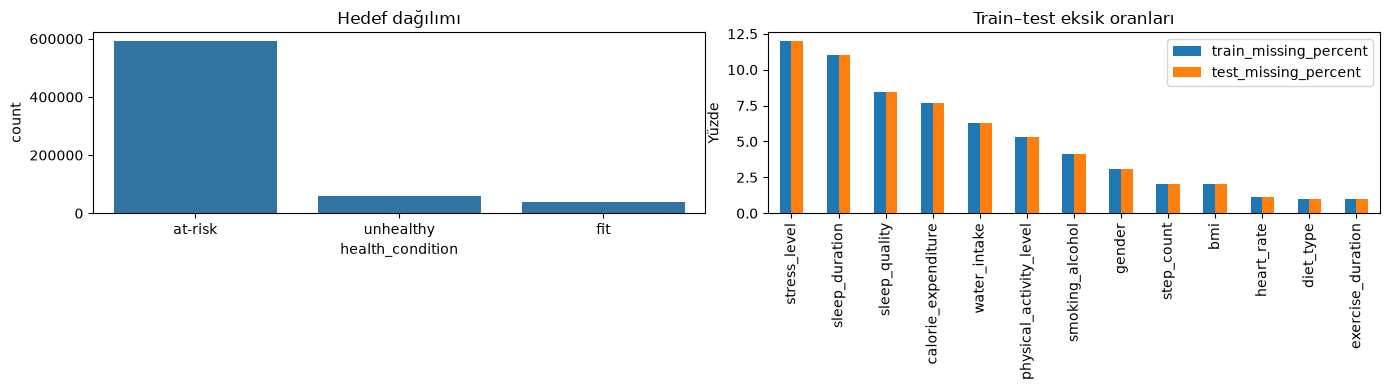

In [3]:
target_summary = train[TARGET].value_counts().to_frame("count")
target_summary["ratio_percent"] = (
    train[TARGET].value_counts(normalize=True).mul(100).round(2)
)

missing_summary = pd.DataFrame({
    "train_missing_percent": train[feature_columns].isna().mean().mul(100),
    "test_missing_percent": test[feature_columns].isna().mean().mul(100),
    "dtype": train[feature_columns].dtypes,
}).sort_values("train_missing_percent", ascending=False)

print("Tam satır duplicate — train/test:", train.duplicated().sum(), test.duplicated().sum())
display(target_summary)
display(missing_summary)
display(train[numeric_columns].describe(percentiles=[0.01, 0.05, 0.95, 0.99]).T)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
sns.countplot(data=train, x=TARGET, order=target_summary.index, ax=axes[0])
axes[0].set_title("Hedef dağılımı")
missing_summary[["train_missing_percent", "test_missing_percent"]].plot.bar(ax=axes[1])
axes[1].set_title("Train–test eksik oranları")
axes[1].set_ylabel("Yüzde")
plt.tight_layout()
plt.show()

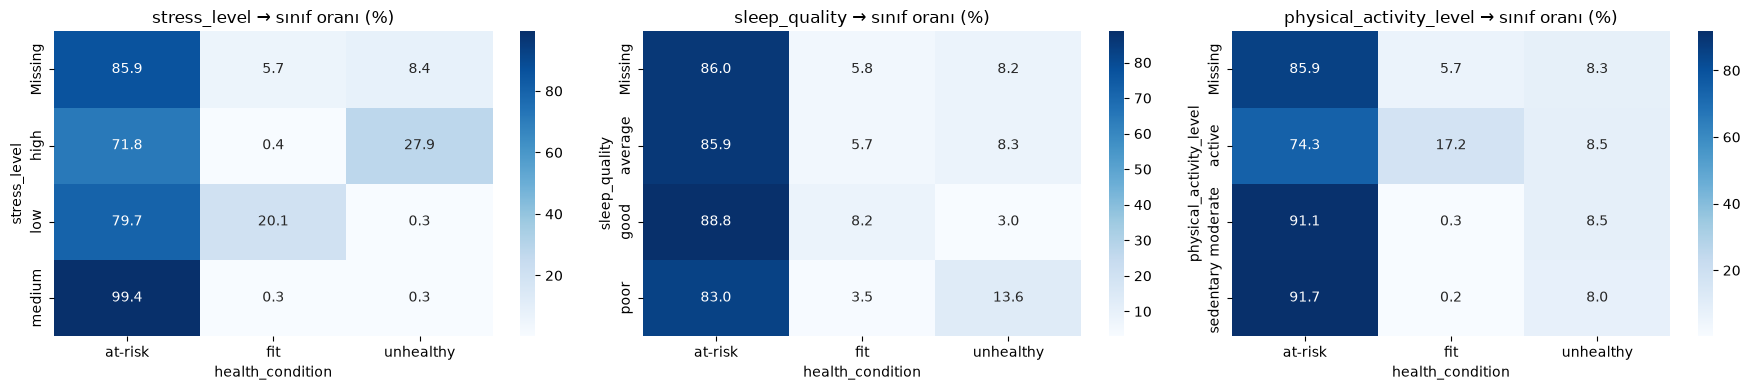

In [4]:
key_categories = ["stress_level", "sleep_quality", "physical_activity_level"]
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

for column, ax in zip(key_categories, axes):
    table = pd.crosstab(
        train[column].fillna("Missing"),
        train[TARGET],
        normalize="index",
    ).mul(100)
    sns.heatmap(table, annot=True, fmt=".1f", cmap="Blues", ax=ax)
    ax.set_title(f"{column} → sınıf oranı (%)")

plt.tight_layout()
plt.show()

## 3. Model verisi ve yardımcı fonksiyonlar

Base modellerde kategorik eksikler `Missing` etiketi olur. Sayısal NaN'lar doldurulmaz;
CatBoost ve LightGBM bunları doğal olarak işler. `LabelEncoder` yalnızca hedefi 0, 1, 2'ye
çevirir. Checkpoint'lerde model yerine OOF ve test olasılıkları saklanır; ensemble için gereken
bilgi budur ve dosyalar çok daha küçüktür.

In [5]:
X = train[feature_columns].copy()
X_test = test[feature_columns].copy()

for column in categorical_columns:
    X[column] = X[column].fillna("Missing")
    X_test[column] = X_test[column].fillna("Missing")

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(train[TARGET])
class_names = label_encoder.classes_
n_classes = len(class_names)
class_prior = np.bincount(y, minlength=n_classes) / len(y)

print(dict(enumerate(class_names)))
print("Class prior:", dict(zip(class_names, class_prior.round(5))))


def normalize_probabilities(probabilities):
    return probabilities / probabilities.sum(axis=1, keepdims=True)


def save_pair(name, oof, test_probability):
    np.save(CHECKPOINT_DIR / f"{name}_oof.npy", oof.astype("float32"))
    np.save(CHECKPOINT_DIR / f"{name}_test.npy", test_probability.astype("float32"))


def load_pair(name):
    oof_path = CHECKPOINT_DIR / f"{name}_oof.npy"
    test_path = CHECKPOINT_DIR / f"{name}_test.npy"
    if oof_path.exists() and test_path.exists():
        print(f"{name}: checkpoint yüklendi")
        return np.load(oof_path), np.load(test_path)
    return None

{0: 'at-risk', 1: 'fit', 2: 'unhealthy'}
Class prior: {'at-risk': np.float64(0.85867), 'fit': np.float64(0.05768), 'unhealthy': np.float64(0.08365)}


## 4. Base model 1 — feature-engineered CatBoost

Etkileşimler tek başına sihirli değildir; EDA'daki davranışları modele daha doğrudan sunar.
Kategorik çaprazlar özellikle stres–uyku–aktivite kombinasyonlarını temsil eder. CatBoost'a
`SqrtBalanced` verilmesinin nedeni azınlık sınıflarını desteklerken tam `Balanced` kadar sert
bir ağırlık uygulamamaktır.

In [6]:
def add_features(dataframe):
    df = dataframe.copy()
    eps = 1e-6

    df["sleep_bmi_interaction"] = df["sleep_duration"] * df["bmi"]
    df["sleep_step_interaction"] = df["sleep_duration"] * df["step_count"]
    df["exercise_step_interaction"] = df["exercise_duration"] * df["step_count"]
    df["sleep_per_bmi"] = df["sleep_duration"] / (df["bmi"] + eps)
    df["calorie_per_exercise"] = df["calorie_expenditure"] / (df["exercise_duration"] + eps)
    df["steps_per_exercise"] = df["step_count"] / (df["exercise_duration"] + eps)

    df["stress_sleep_quality"] = df["stress_level"].astype(str) + "_" + df["sleep_quality"].astype(str)
    df["stress_activity"] = df["stress_level"].astype(str) + "_" + df["physical_activity_level"].astype(str)
    df["sleep_quality_activity"] = df["sleep_quality"].astype(str) + "_" + df["physical_activity_level"].astype(str)
    return df


X_fe = add_features(X)
X_test_fe = add_features(X_test)
fe_categorical_columns = categorical_columns + [
    "stress_sleep_quality",
    "stress_activity",
    "sleep_quality_activity",
]


def train_base_catboost():
    cached = load_pair("base_catboost_fe")
    if cached is not None:
        return cached

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    oof = np.zeros((len(X_fe), n_classes), dtype="float32")
    test_sum = np.zeros((len(X_test_fe), n_classes), dtype="float32")

    for fold, (train_idx, valid_idx) in enumerate(cv.split(X_fe, y), 1):
        print(f"CatBoost fold {fold}/3")

        valid_model = CatBoostClassifier(
            iterations=500, learning_rate=0.08, depth=7,
            loss_function="MultiClass", eval_metric="MultiClass",
            auto_class_weights="SqrtBalanced", random_seed=42 + fold,
            allow_writing_files=False, verbose=100,
        )
        valid_model.fit(
            X_fe.iloc[train_idx], y[train_idx],
            eval_set=(X_fe.iloc[valid_idx], y[valid_idx]),
            cat_features=fe_categorical_columns,
            early_stopping_rounds=75,
        )
        oof[valid_idx] = valid_model.predict_proba(X_fe.iloc[valid_idx])

        test_model = CatBoostClassifier(
            iterations=500, learning_rate=0.08, depth=7,
            loss_function="MultiClass", eval_metric="MultiClass",
            auto_class_weights="SqrtBalanced", random_seed=42 + fold,
            allow_writing_files=False, verbose=100,
        )
        test_model.fit(
            X_fe.iloc[train_idx], y[train_idx],
            cat_features=fe_categorical_columns,
        )
        test_sum += test_model.predict_proba(X_test_fe).astype("float32") / 3
        del valid_model, test_model
        gc.collect()

    save_pair("base_catboost_fe", oof, test_sum)
    return oof, test_sum


cat_oof, cat_test = train_base_catboost()
print("CatBoost raw OOF:", round(balanced_accuracy_score(y, cat_oof.argmax(1)), 6))

CatBoost fold 1/3
0:	learn: 0.9678309	test: 0.9676632	best: 0.9676632 (0)	total: 4.64s	remaining: 38m 37s
100:	learn: 0.1542268	test: 0.1522932	best: 0.1522932 (100)	total: 5m 43s	remaining: 22m 36s
200:	learn: 0.1497192	test: 0.1496337	best: 0.1496337 (200)	total: 8m 59s	remaining: 13m 22s
300:	learn: 0.1462544	test: 0.1485972	best: 0.1485972 (300)	total: 12m 11s	remaining: 8m 3s
400:	learn: 0.1433737	test: 0.1482893	best: 0.1482738 (391)	total: 17m 5s	remaining: 4m 13s
499:	learn: 0.1407188	test: 0.1481294	best: 0.1481283 (498)	total: 24m 48s	remaining: 0us

bestTest = 0.1481283238
bestIteration = 498

Shrink model to first 499 iterations.
0:	learn: 0.9678309	total: 1.23s	remaining: 10m 13s
100:	learn: 0.1542268	total: 1m 28s	remaining: 5m 48s
200:	learn: 0.1497192	total: 2m 45s	remaining: 4m 6s
300:	learn: 0.1462544	total: 4m	remaining: 2m 39s
400:	learn: 0.1433737	total: 5m 16s	remaining: 1m 18s
499:	learn: 0.1407188	total: 6m 29s	remaining: 0us
CatBoost fold 2/3
0:	learn: 0.967234

## 5. Base model 2 — native kategorik LightGBM

İkinci model farklı bir öğrenme mekanizması sunduğu için CatBoost hatalarının bir bölümünü
düzeltir. Sınıf ağırlığı olarak karekök ters frekans kullanılır. `category` dtype sayesinde
kategorik sütunlar one-hot'a çevrilmeden LightGBM tarafından işlenir.

In [7]:
X_lgb = X.copy()
X_test_lgb = X_test.copy()
for column in categorical_columns:
    X_lgb[column] = X_lgb[column].astype("category")
    X_test_lgb[column] = X_test_lgb[column].astype("category")

class_counts = pd.Series(y).value_counts().sort_index()
class_weights = np.sqrt(len(y) / (n_classes * class_counts))
sample_weights = pd.Series(y).map(class_weights.to_dict()).to_numpy()


def train_base_lightgbm():
    cached = load_pair("base_lightgbm")
    if cached is not None:
        return cached

    cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    oof = np.zeros((len(X_lgb), n_classes), dtype="float32")
    test_sum = np.zeros((len(X_test_lgb), n_classes), dtype="float32")

    for fold, (train_idx, valid_idx) in enumerate(cv.split(X_lgb, y), 1):
        print(f"LightGBM fold {fold}/3")
        params = dict(
            objective="multiclass", num_class=n_classes,
            n_estimators=800, learning_rate=0.05, num_leaves=63,
            max_depth=-1, subsample=0.9, colsample_bytree=0.9,
            random_state=42 + fold, n_jobs=-1, verbose=-1,
        )

        valid_model = LGBMClassifier(**params)
        valid_model.fit(
            X_lgb.iloc[train_idx], y[train_idx],
            sample_weight=sample_weights[train_idx],
            eval_set=[(X_lgb.iloc[valid_idx], y[valid_idx])],
            eval_metric="multi_logloss",
            callbacks=[lgb.early_stopping(75, verbose=False)],
        )
        oof[valid_idx] = valid_model.predict_proba(X_lgb.iloc[valid_idx])

        test_model = LGBMClassifier(**params)
        test_model.fit(
            X_lgb.iloc[train_idx], y[train_idx],
            sample_weight=sample_weights[train_idx],
        )
        test_sum += test_model.predict_proba(X_test_lgb).astype("float32") / 3
        del valid_model, test_model
        gc.collect()

    save_pair("base_lightgbm", oof, test_sum)
    return oof, test_sum


lgb_oof, lgb_test = train_base_lightgbm()
print("LightGBM raw OOF:", round(balanced_accuracy_score(y, lgb_oof.argmax(1)), 6))

LightGBM fold 1/3
LightGBM fold 2/3
LightGBM fold 3/3
LightGBM raw OOF: 0.928975


In [8]:
BASE_CAT_WEIGHT = 0.55
BASE_LGB_WEIGHT = 0.45
BASE_PRIOR_BETA = 0.58

base_oof = BASE_CAT_WEIGHT * cat_oof + BASE_LGB_WEIGHT * lgb_oof
base_test = BASE_CAT_WEIGHT * cat_test + BASE_LGB_WEIGHT * lgb_test

base_balanced_oof = normalize_probabilities(
    base_oof / np.power(class_prior, BASE_PRIOR_BETA)
)
base_balanced_test = normalize_probabilities(
    base_test / np.power(class_prior, BASE_PRIOR_BETA)
)

print("Düzeltilmiş base OOF:", round(
    balanced_accuracy_score(y, base_balanced_oof.argmax(1)), 6
))

Düzeltilmiş base OOF: 0.949612


## 6. Ana model — leakage-safe Target-Encoding LightGBM

En büyük sıçrama bu modelden geldi. Target encoding, bir değeri o gruptaki hedef oranlarıyla
temsil eder. En önemli risk **target leakage**'tır. Bu nedenle encoder her fold içinde yalnızca
fold-train hedefleriyle öğrenir; validation ve test hedefi asla görülmez.

Hem 13 ham sütun hem de 48 target-encoded sütun kullanılır. Üç seed ve 7 fold, tek bir split'e
bağlı şansı azaltır. Toplam 21 model eğitilir ve olasılıkları ortalanır.

In [9]:
TE_COLUMNS = numeric_columns + categorical_columns
TE_INTERACTIONS = [
    ["stress_level", "sleep_quality"],
    ["stress_level", "physical_activity_level"],
    ["sleep_quality", "physical_activity_level"],
]
TE_SEEDS = [42, 202607, 202627]
TE_N_SPLITS = 7

X_te_raw = train[feature_columns].copy()
X_te_test_raw = test[feature_columns].copy()


def convert_native_categories(dataframe):
    converted = dataframe.copy()
    for column in categorical_columns:
        converted[column] = converted[column].astype("category")
    return converted


def combine_raw_and_te_features(raw_dataframe, encoded_values):
    raw_features = convert_native_categories(raw_dataframe).reset_index(drop=True)
    encoded_values = np.asarray(encoded_values, dtype="float32")
    encoded_features = pd.DataFrame(
        encoded_values,
        columns=[f"te_{i}" for i in range(encoded_values.shape[1])],
    )
    return pd.concat([raw_features, encoded_features], axis=1)


def train_te_seed(seed):
    name = f"te_lgb_seed_{seed}"
    cached = load_pair(name)
    if cached is not None:
        return cached

    partial_oof_path = CHECKPOINT_DIR / f"{name}_partial_oof.npy"
    partial_test_path = CHECKPOINT_DIR / f"{name}_partial_test_sum.npy"
    completed_path = CHECKPOINT_DIR / f"{name}_completed_folds.npy"

    oof = np.load(partial_oof_path) if partial_oof_path.exists() else np.zeros(
        (len(train), n_classes), dtype="float32"
    )
    test_sum = np.load(partial_test_path) if partial_test_path.exists() else np.zeros(
        (len(test), n_classes), dtype="float32"
    )
    completed = set(np.load(completed_path).astype(int)) if completed_path.exists() else set()
    cv = StratifiedKFold(n_splits=TE_N_SPLITS, shuffle=True, random_state=seed)

    for fold, (train_idx, valid_idx) in enumerate(cv.split(X_te_raw, y), 1):
        if fold in completed:
            print(f"Seed {seed}, fold {fold}: checkpoint bulundu")
            continue

        print(f"Seed {seed}, fold {fold}/{TE_N_SPLITS}")
        X_train_raw = X_te_raw.iloc[train_idx].copy()
        X_valid_raw = X_te_raw.iloc[valid_idx].copy()

        encoder = TargetEncoder(
            random_state=seed + fold,
            cols=TE_COLUMNS,
            stats=("mean",),
            smooth="auto",
            target_type="multiclass",
            numeric="direct",
            interactions=TE_INTERACTIONS,
        )
        train_encoded = encoder.fit_transform(
            X_train_raw[TE_COLUMNS].reset_index(drop=True), y[train_idx]
        )
        valid_encoded = encoder.transform(
            X_valid_raw[TE_COLUMNS].reset_index(drop=True)
        )
        test_encoded = encoder.transform(
            X_te_test_raw[TE_COLUMNS].reset_index(drop=True)
        )

        X_train_combined = combine_raw_and_te_features(X_train_raw, train_encoded)
        X_valid_combined = combine_raw_and_te_features(X_valid_raw, valid_encoded)
        X_test_combined = combine_raw_and_te_features(X_te_test_raw, test_encoded)

        model = LGBMClassifier(
            objective="multiclass", boosting_type="gbdt", num_class=n_classes,
            n_estimators=2000, learning_rate=0.05, num_leaves=31,
            min_child_samples=20, max_depth=-1, max_bin=255,
            subsample=1.0, subsample_freq=0, colsample_bytree=1.0,
            reg_lambda=0.0, reg_alpha=0.0,
            random_state=seed + fold, n_jobs=-1, verbose=-1,
        )
        model.fit(
            X_train_combined, y[train_idx],
            eval_set=[(X_valid_combined, y[valid_idx])],
            eval_metric="multi_logloss",
            callbacks=[
                lgb.early_stopping(50, verbose=False),
                lgb.log_evaluation(100),
            ],
        )

        oof[valid_idx] = model.predict_proba(X_valid_combined).astype("float32")
        test_sum += model.predict_proba(X_test_combined).astype("float32")
        completed.add(fold)

        np.save(partial_oof_path, oof)
        np.save(partial_test_path, test_sum)
        np.save(completed_path, np.array(sorted(completed)))

        del (
            encoder, train_encoded, valid_encoded, test_encoded,
            X_train_combined, X_valid_combined, X_test_combined,
            X_train_raw, X_valid_raw, model,
        )
        gc.collect()

    test_probability = test_sum / TE_N_SPLITS
    save_pair(name, oof, test_probability)
    return oof, test_probability

In [10]:
te_probability_pairs = {}

for seed in TE_SEEDS:
    te_probability_pairs[seed] = train_te_seed(seed)

multiseed_te_oof = np.mean(
    [pair[0] for pair in te_probability_pairs.values()], axis=0
)
multiseed_te_test = np.mean(
    [pair[1] for pair in te_probability_pairs.values()], axis=0
)
save_pair("te_lgb_multiseed_3", multiseed_te_oof, multiseed_te_test)

print("Multi-seed TE raw OOF:", round(
    balanced_accuracy_score(y, multiseed_te_oof.argmax(1)), 6
))

Seed 42, fold 1/7
[100]	valid_0's multi_logloss: 0.0874712
[200]	valid_0's multi_logloss: 0.0870073
Seed 42, fold 2/7
[100]	valid_0's multi_logloss: 0.0861861
[200]	valid_0's multi_logloss: 0.0855466
[300]	valid_0's multi_logloss: 0.0855314
Seed 42, fold 3/7
[100]	valid_0's multi_logloss: 0.0866986
[200]	valid_0's multi_logloss: 0.086142
Seed 42, fold 4/7
[100]	valid_0's multi_logloss: 0.0900264
[200]	valid_0's multi_logloss: 0.0895519
Seed 42, fold 5/7
[100]	valid_0's multi_logloss: 0.0871362
[200]	valid_0's multi_logloss: 0.0865997
Seed 42, fold 6/7
[100]	valid_0's multi_logloss: 0.0873082
[200]	valid_0's multi_logloss: 0.0866814
[300]	valid_0's multi_logloss: 0.086627
Seed 42, fold 7/7
[100]	valid_0's multi_logloss: 0.090124
[200]	valid_0's multi_logloss: 0.0896126
Seed 202607, fold 1/7
[100]	valid_0's multi_logloss: 0.0868937
[200]	valid_0's multi_logloss: 0.0864121
Seed 202607, fold 2/7
[100]	valid_0's multi_logloss: 0.0905267
[200]	valid_0's multi_logloss: 0.0900201
Seed 202607, 

## 7. Prior correction ve final blend

Balanced accuracy her sınıfın recall değerine eşit önem verir. Eğitim dağılımı ise çoğunluk
sınıfını olasılık olarak avantajlı hale getirir. Prior correction, tahmin olasılıklarını sınıf
frekansının `beta` kuvvetine bölerek bu avantajı kontrollü biçimde azaltır.

`beta=1.02`, TE ağırlığı `0.85` ve base ağırlığı `0.15` OOF üzerinde seçildi. Bu değerler
leaderboard'a bakılarak ayarlanmadı; aynı dönüşüm teste değiştirilmeden uygulanır.

Final OOF balanced accuracy: 0.950614
              precision    recall  f1-score   support

     at-risk     0.9937    0.9363    0.9641    592561
         fit     0.7286    0.9506    0.8249     39803
   unhealthy     0.6980    0.9649    0.8100     57724

    accuracy                         0.9395    690088
   macro avg     0.8067    0.9506    0.8664    690088
weighted avg     0.9537    0.9395    0.9432    690088



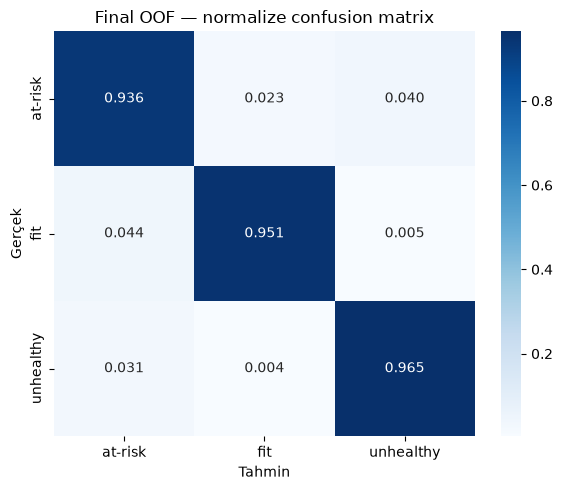

In [11]:
FINAL_TE_BETA = 1.02
FINAL_TE_WEIGHT = 0.85
FINAL_BASE_WEIGHT = 0.15

corrected_te_oof = normalize_probabilities(
    multiseed_te_oof / np.power(class_prior, FINAL_TE_BETA)
)
corrected_te_test = normalize_probabilities(
    multiseed_te_test / np.power(class_prior, FINAL_TE_BETA)
)

final_oof = normalize_probabilities(
    FINAL_TE_WEIGHT * corrected_te_oof
    + FINAL_BASE_WEIGHT * base_balanced_oof
)
final_test = normalize_probabilities(
    FINAL_TE_WEIGHT * corrected_te_test
    + FINAL_BASE_WEIGHT * base_balanced_test
)

final_oof_predictions = final_oof.argmax(axis=1)
final_oof_score = balanced_accuracy_score(y, final_oof_predictions)

print("Final OOF balanced accuracy:", round(final_oof_score, 6))
print(classification_report(
    y, final_oof_predictions,
    target_names=class_names,
    digits=4,
))

matrix = confusion_matrix(y, final_oof_predictions, normalize="true")
plt.figure(figsize=(6, 5))
sns.heatmap(
    matrix, annot=True, fmt=".3f", cmap="Blues",
    xticklabels=class_names, yticklabels=class_names,
)
plt.title("Final OOF — normalize confusion matrix")
plt.xlabel("Tahmin")
plt.ylabel("Gerçek")
plt.tight_layout()
plt.show()

## 8. Final submission

Dosya adı geçmişte gönderdiğimiz en iyi submission ile aynıdır. Son kontroller ID sırasını,
satır sayısını, eksik tahmini ve geçerli sınıfları doğrular.

In [12]:
test_encoded_predictions = final_test.argmax(axis=1)
test_predictions = label_encoder.inverse_transform(test_encoded_predictions)

submission = sample_submission.copy()
submission[TARGET] = test_predictions

assert len(submission) == len(test)
assert np.array_equal(submission[ID_COLUMN].to_numpy(), test[ID_COLUMN].to_numpy())
assert submission[TARGET].isna().sum() == 0
assert set(submission[TARGET].unique()) <= set(class_names)

submission_path = OUTPUT_DIR / "submission_te_lgb_multiseed3_085_base015_beta102.csv"
submission.to_csv(submission_path, index=False)

print("Saved:", submission_path.resolve())
print("Submission shape:", submission.shape)
print()
print("Tahmin dağılımı (%):")
display(submission[TARGET].value_counts(normalize=True).mul(100).round(2))
display(submission.head())

Saved: ./submission_te_lgb_multiseed3_085_base015_beta102.csv
Submission shape: (295753, 2)

Tahmin dağılımı (%):


health_condition
at-risk      81.09
unhealthy    11.50
fit           7.40
Name: proportion, dtype: float64

,id,health_condition
0,690088,unhealthy
1,690089,unhealthy
2,690090,at-risk
3,690091,at-risk
4,690092,unhealthy


## Sonuç

Elde edilen sonucu tek bir “daha büyük model” değil, şu kararlar getirdi:

- Dengesiz hedefe uygun metrik ve stratified validation
- Fold-safe target encoding
- Farklı seed'lerle varyansı azaltma
- Birbirinden farklı modellerin olasılık seviyesinde birleşimi
- Sınıf prior düzeltmesini yalnızca OOF ile seçme
- Public leaderboard yerine fold tutarlılığını esas alma

Beklenen küçük skor farkları LightGBM, CatBoost ve `catstat` sürümlerinden kaynaklanabilir.
Aynı ortam ve checkpoint'lerle üretilen submission yarışmadaki en iyi pipeline'ımızdır.